In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
import sys
sys.path.append('../.')
from simple_reader import load_all_benchmarks, plot_normalized_scaling, chunk_translation
from aqua.graphics import ConfigStyle

%load_ext autoreload
%autoreload 2

/opt/homebrew/Caskroom/miniconda/base/envs/aqua/lib/python3.12/site-packages/intake_esm/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## Plot pure benchmark results

In [24]:
results = load_all_benchmarks('array/results_*Dchunk*.txt')
results

Found 6 benchmark files matching pattern 'array/results_*Dchunk*.txt'.


,Attempt,Total Time (s),Retrieve Time (s),Compute Time (s),I/O Time (s),Variable,Workers,Memory (GB),Chunk Size
0,1,14.64,2.75,11.87,0.02,2t,16,128,D
1,2,15.12,2.81,12.30,0.02,2t,16,128,D
2,3,14.73,2.76,11.96,0.02,2t,16,128,D
3,1,22.77,2.57,20.19,0.02,2t,8,128,D
4,2,23.35,2.55,20.79,0.02,2t,8,128,D
5,3,23.32,2.55,20.75,0.02,2t,8,128,D
6,1,39.64,2.58,37.04,0.02,2t,4,128,D
7,2,39.15,2.58,36.56,0.02,2t,4,128,D
8,3,40.50,2.54,37.94,0.02,2t,4,128,D
9,1,79.09,2.57,76.49,0.02,2t,2,128,D


In [25]:
results_chunk = load_all_benchmarks('array/results_*32*.txt')
results_chunk = chunk_translation(results_chunk)
results_chunk

Found 4 benchmark files matching pattern 'array/results_*32*.txt'.


,Attempt,Total Time (s),Retrieve Time (s),Compute Time (s),I/O Time (s),Variable,Workers,Memory (GB),Chunk Size
0,1,29.03,2.83,26.15,0.04,2t,32,128,3
1,2,29.60,2.79,26.78,0.03,2t,32,128,3
2,3,29.47,2.79,26.65,0.03,2t,32,128,3
3,1,66.94,3.34,63.53,0.07,2t,32,128,1
4,2,67.39,3.04,64.26,0.09,2t,32,128,1
5,3,67.89,3.05,64.76,0.07,2t,32,128,1
6,1,23.28,2.92,20.33,0.03,2t,32,128,6
7,2,22.12,2.89,19.20,0.03,2t,32,128,6
8,3,21.71,3.05,18.63,0.03,2t,32,128,6
9,1,12.96,2.80,10.14,0.02,2t,32,128,24


In [31]:
test = results_chunk.groupby(['Workers', 'Chunk Size', 'Variable'])['Total Time (s)'].mean().reset_index(name='Mean Time')
test

,Workers,Chunk Size,Variable,Mean Time
0,32,1,2t,67.406667
1,32,3,2t,29.366667
2,32,6,2t,22.370000
3,32,24,2t,12.373333


In [32]:
baseline_time = test.sort_values('Chunk Size').iloc[0]['Mean Time']
baseline_time

np.float64(67.40666666666667)

In [87]:
def plot_normalized_scaling_and_chunking(df_scaling, df_chunking, which_time='Total Time (s)', log_scale=False, title=None):

    ConfigStyle()

    # Dataset management
    df_scaling_avg =(
        df_scaling.groupby(['Workers', 'Memory (GB)', 'Variable'])[which_time]
        .mean()
        .reset_index(name='Mean Time')
    )
    df_chunking_avg =(
        df_chunking.groupby(['Workers', 'Chunk Size', 'Variable'])[which_time]
        .mean()
        .reset_index(name='Mean Time')
    )
    normalized_scaling = []
    normalized_chunking = []

    for mem, group in df_scaling_avg.groupby('Memory (GB)'):
        baseline_time = group.sort_values('Workers').iloc[0]['Mean Time']
        group = group.copy()
        group['Normalized Speedup'] = baseline_time / group['Mean Time']
        normalized_scaling.append(group)
    for chunk, group in df_chunking_avg.groupby('Workers'):
        baseline_time = group.sort_values('Chunk Size').iloc[0]['Mean Time']
        group = group.copy()
        group['Normalized Speedup'] = baseline_time / group['Mean Time']
        normalized_chunking.append(group)

    df_normalized_scaling = pd.concat(normalized_scaling)
    df_normalized_chunking = pd.concat(normalized_chunking)


    # Update the 'Memory (GB)' column to include units for legend clarity
    df_normalized_scaling = df_normalized_scaling.copy()
    df_normalized_scaling['Memory Label'] = df_normalized_scaling['Memory (GB)'].astype(str) + ' GB'

    # Plot the two dataframes in two subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

    sns.lineplot(data=df_normalized_scaling,
                 x='Workers', y='Normalized Speedup',
                 hue='Memory Label',  marker='o',
                 palette='viridis',
                 linewidth=2,
                 legend='auto',
                    ax=axes[0])

    sns.lineplot(data=df_normalized_chunking,
                 x='Chunk Size', y='Normalized Speedup',
                 hue='Workers',  marker='o',
                 palette='viridis',
                 linewidth=2,
                 legend='auto',
                 ax=axes[1])

    # Perfect scaling line
    workers_sorted = sorted(df_normalized_scaling['Workers'].unique())
    axes[0].plot(workers_sorted, np.array(workers_sorted)/workers_sorted[0],
                 linestyle='--', color='gray', label='Perfect Scaling')
    
    # Graphical adjustments
    titles_fontsize = 20
    labels_fontsize = 16
    tickers_fontsize = 14

    axes[0].set_title('Normalized Scaling by Workers', fontsize=titles_fontsize)
    axes[1].set_title('Normalized Scaling by Chunk Size', fontsize=titles_fontsize)
    axes[0].set_xlabel('Workers', fontsize=labels_fontsize)
    axes[1].set_xlabel('Chunk Size [Hours]', fontsize=labels_fontsize)
    axes[0].set_ylabel('Normalized Speedup', fontsize=labels_fontsize)
    axes[1].set_ylabel('Normalized Speedup', fontsize=labels_fontsize)
    axes[0].set_xscale('log')
    # axes[1].set_xscale('log')
    axes[0].set_yscale('log' if log_scale else 'linear')
    axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}x'))
    axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}x'))
    axes[0].tick_params(axis='both', which='major', labelsize=tickers_fontsize)
    axes[1].tick_params(axis='both', which='major', labelsize=tickers_fontsize)
    axes[0].legend(title='Memory (GB)', loc='upper left', fontsize='large', title_fontsize=titles_fontsize)
    axes[1].legend(title='Workers', loc='upper left', fontsize='large', title_fontsize=titles_fontsize)
    if title:
        fig.suptitle(title, fontsize=titles_fontsize + 2, fontweight='bold')
    plt.tight_layout()
    plt.show()

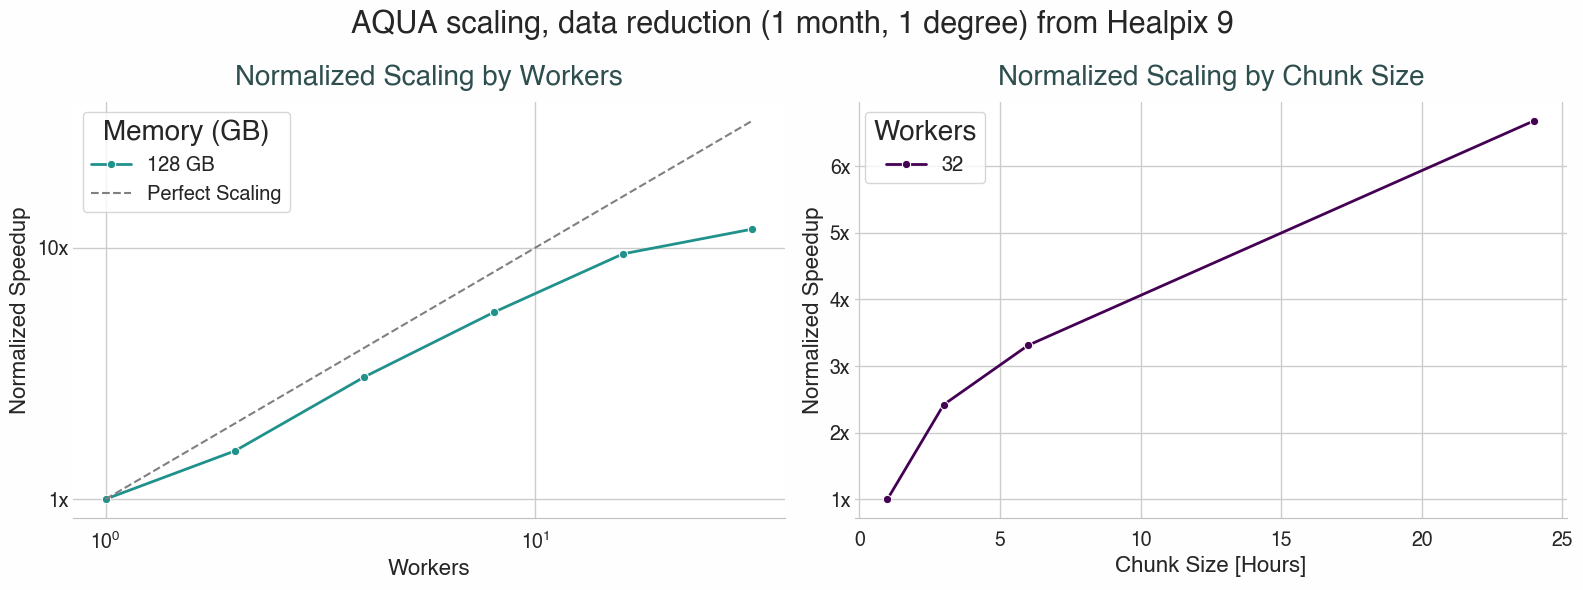

In [89]:
plot_normalized_scaling_and_chunking(results, results_chunk, which_time='Compute Time (s)', log_scale=True,
                                     title='AQUA scaling, data reduction (1 month, 1 degree) from Healpix 9')

## Soft scaling

We open the data which are reported as a table, no plot needed.

In [92]:
results_soft = load_all_benchmarks('soft_scaling_2d/results_*Dchunk*.txt')
soft_scaling_avg =(
        results_soft.groupby(['Workers', 'Memory (GB)', 'Variable'])['Total Time (s)']
        .mean()
        .reset_index(name='Mean Time')
    )

Found 3 benchmark files matching pattern 'soft_scaling_2d/results_*Dchunk*.txt'.


In [93]:
soft_scaling_avg

,Workers,Memory (GB),Variable,Mean Time
0,8,128,2t,62.476667
1,16,128,2t,57.106667
2,32,128,2t,64.403333


## 3D scaling

In [3]:
results_3d = load_all_benchmarks('array3D/results_*chunk*.txt')

Found 4 benchmark files matching pattern 'array3D/results_*chunk*.txt'.


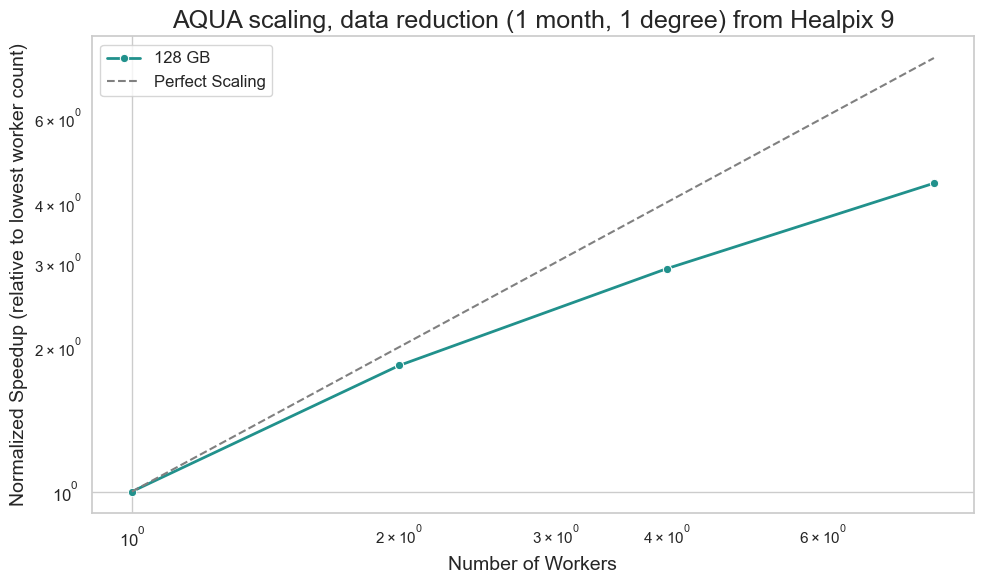

In [6]:
plot_normalized_scaling(results_3d, which_time='Total Time (s)', logx=True, logy=True,
                        title='AQUA scaling, data reduction (1 month, 1 degree) from Healpix 9')